In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


In [5]:
print(y_train[:10])

[9 0 0 3 0 2 7 2 5 5]


In [7]:
label = y_train[0]
print(label)

9


In [8]:
print(class_names[label])

Ankle Boot


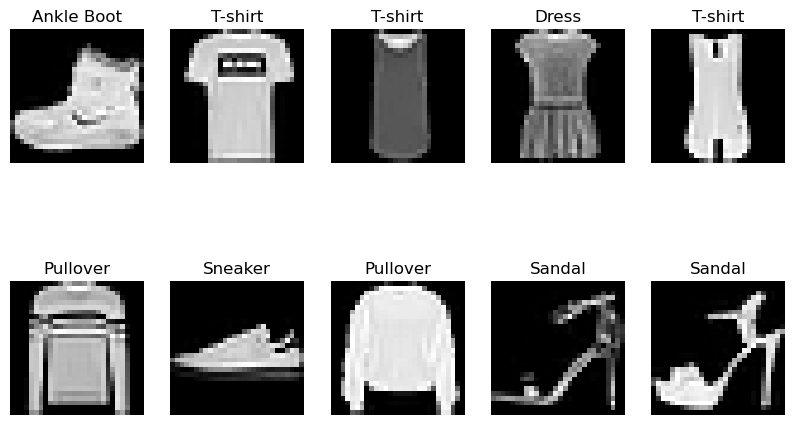

In [9]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

# Normalize Images

In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape Images

In [11]:
# CNN expects 4D input
# (samples, height, width, channels)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [13]:
# Check shape
print(x_train.shape)

(60000, 28, 28, 1)


# Build CNN Model 

In [14]:
model = Sequential()

model.add(Input(shape=(28,28,1)))

model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# model summary

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8070 - loss: 0.5328 - val_accuracy: 0.8781 - val_loss: 0.3255
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8745 - loss: 0.3479 - val_accuracy: 0.8982 - val_loss: 0.2764
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8913 - loss: 0.3013 - val_accuracy: 0.9023 - val_loss: 0.2522
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9028 - loss: 0.2684 - val_accuracy: 0.9101 - val_loss: 0.2422
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9089 - loss: 0.2480 - val_accuracy: 0.9141 - val_loss: 0.2299
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9168 - loss: 0.2276 - val_accuracy: 0.9164 - val_loss: 0.2265
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9226 - loss: 0.2075 - val_accuracy: 0.9202 - val_loss: 0.2207
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9294 - loss

# Evaluate Model

In [18]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9155 - loss: 0.2464
Loss : 0.24635136127471924
Accuracy : 0.9154999852180481


# Plot Accuracy and  Loss

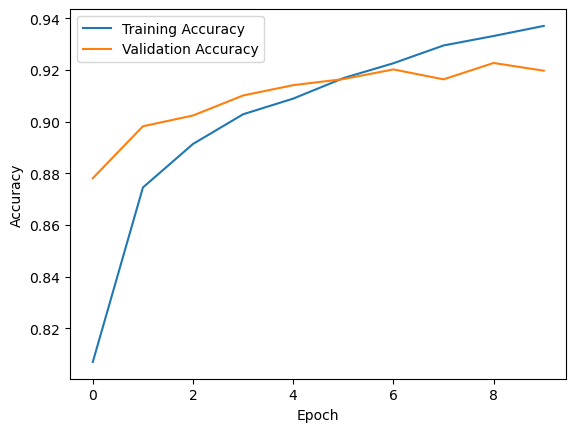

In [20]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

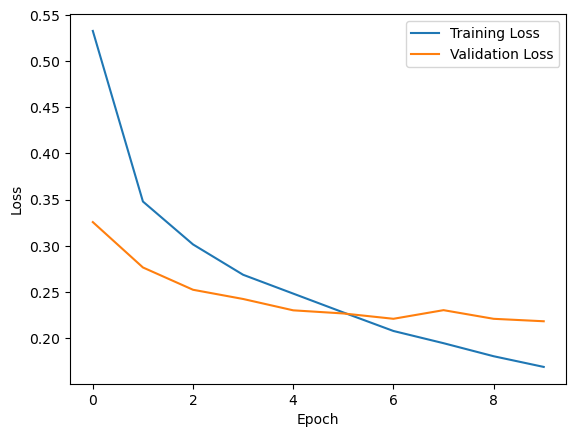

In [21]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Predict

In [22]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


# Predicted Class

In [23]:
predicted_class = np.argmax(predictions[0])

print("Predicted :", class_names[predicted_class])
print("Actual :", class_names[y_test[0]])

Predicted : Ankle Boot
Actual : Ankle Boot


# Show Prediction

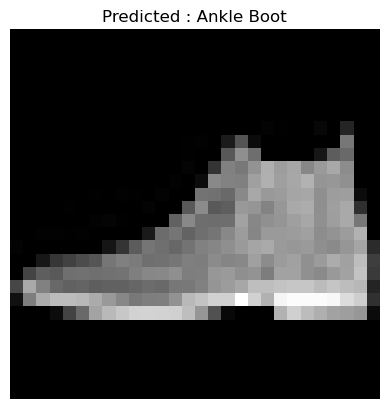

In [24]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted : {class_names[predicted_class]}")
plt.axis("off")
plt.show()